# MINOS 2D Event Display (Matplotlib)

This notebook loads the local ROOT SNTP file and renders the 2D MINOS perspectives for a given event index using Matplotlib.

- **2D Panel Display**:
  - Top Panel: Perspective 1 (U View: `planeview 2`)
  - Bottom Panel: Perspective 2 (V View: `planeview 3`)
- The two panels share the plane axis on x, while the strip axis is shown on y with the second perspective mirrored to reflect detector strip orientation.
- Pulse height from `ph0.pe` and `ph1.pe` is used as pixel intensity channel (`turbo` colormap).


In [1]:
%pip install -q uproot awkward numpy pandas matplotlib

from pathlib import Path
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot

root_file = Path('f21048000_0000_L010185N_D07_r3.sntp.dogwood5.0.root')
if not root_file.exists():
    root_file = Path('minos_sparse/f21048000_0000_L010185N_D07_r3.sntp.dogwood5.0.root')
assert root_file.exists(), f'Missing ROOT file: {root_file}'
print(f'Using ROOT file: {root_file}')


Note: you may need to restart the kernel to use updated packages.


Using ROOT file: f21048000_0000_L010185N_D07_r3.sntp.dogwood5.0.root


In [2]:
EVENT_INDEX = 0

root_handle = uproot.open(root_file)
tree = root_handle['NtpSt;1']
print(f'Loaded tree NtpSt;1 with {tree.num_entries} total events.')


Loaded tree NtpSt;1 with 119205 total events.


Event 0 MC Truth: nu_mu | Type: CC | Channel: RES | True E_nu = 2.76 GeV


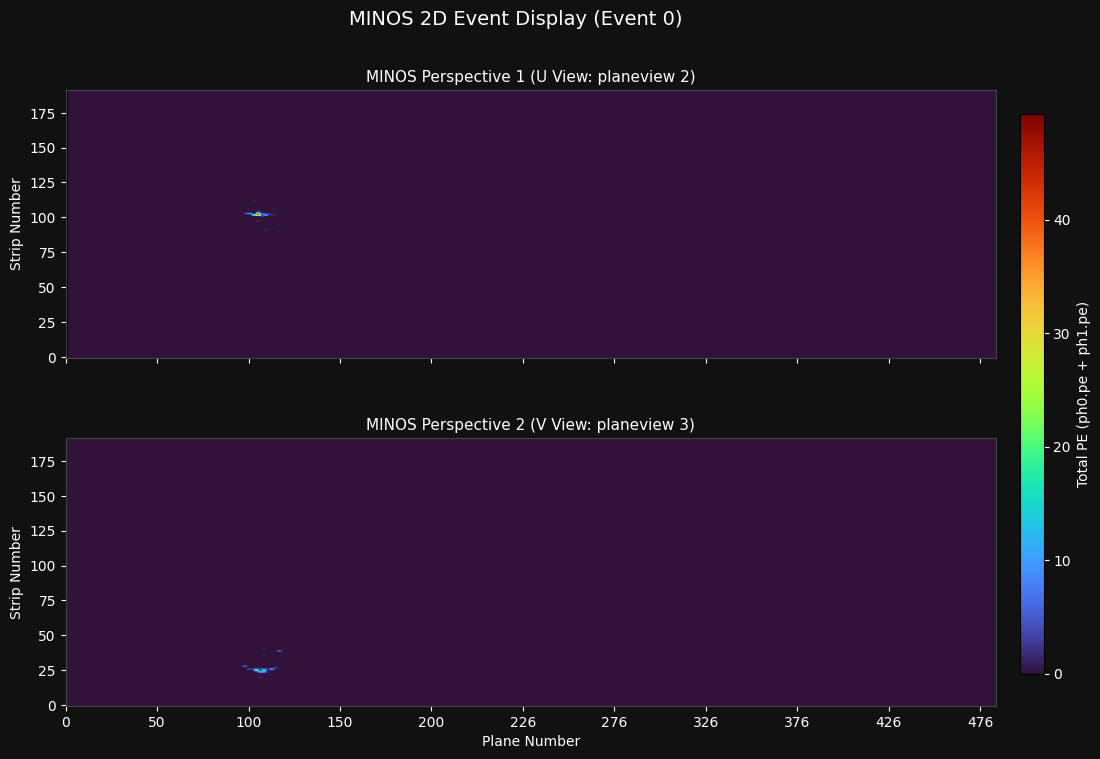

In [3]:
plane_min, plane_max = 1, 485
strip_min, strip_max = 0, 191
gap_columns = 24
gap_start = 244
all_disp_planes = [p if p < gap_start else p + gap_columns for p in range(plane_min, plane_max + 1)]
u_raw = [p for p in range(plane_min, plane_max + 1) if (p % 2 == 0 if p < 250 else p % 2 == 1)]
v_raw = [p for p in range(plane_min, plane_max + 1) if (p % 2 == 1 if p < 250 else p % 2 == 0)]
u_planes = [p if p < gap_start else p + gap_columns for p in u_raw]
v_planes = [p if p < gap_start else p + gap_columns for p in v_raw]
full_strips = list(range(strip_min, strip_max + 1))

tick_positions = list(range(0, 550, 50))
tick_text_list = [str(p) if p < gap_start else str(p - gap_columns) for p in tick_positions]

NEUTRINO_FLAVORS = {14: "nu_mu", -14: "nu_bar_mu", 12: "nu_e", -12: "nu_bar_e", 16: "nu_tau", -16: "nu_bar_tau"}
INTERACTION_CURRENTS = {1: "CC", 0: "NC"}
INTERACTION_CHANNELS = {1001: "QE", 1002: "RES", 1003: "DIS", 1004: "COH"}

req_branches = [
    "NtpStRecord/stp/stp.planeview",
    "NtpStRecord/stp/stp.strip",
    "NtpStRecord/stp/stp.plane",
    "NtpStRecord/stp/stp.ph0.pe",
    "NtpStRecord/stp/stp.ph1.pe",
    "NtpStRecord/mc/mc.inu",
    "NtpStRecord/mc/mc.iaction",
    "NtpStRecord/mc/mc.iresonance",
    "NtpStRecord/mc/mc.p4neu[4]",
]

event = tree.arrays(req_branches, entry_start=EVENT_INDEX, entry_stop=EVENT_INDEX+1, library="ak")[0]

planeview = ak.to_list(event["NtpStRecord/stp/stp.planeview"])
strip = ak.to_list(event["NtpStRecord/stp/stp.strip"])
plane = ak.to_list(event["NtpStRecord/stp/stp.plane"])
ph0_pe = ak.to_list(event["NtpStRecord/stp/stp.ph0.pe"])
ph1_pe = ak.to_list(event["NtpStRecord/stp/stp.ph1.pe"])
total_pe = [east + west for east, west in zip(ph0_pe, ph1_pe)]
vmax = max(total_pe) if total_pe else 1.0

# Print MC Truth
try:
    inu_val = ak.to_list(event["NtpStRecord/mc/mc.inu"])[0]
    iact_val = ak.to_list(event["NtpStRecord/mc/mc.iaction"])[0]
    ires_val = ak.to_list(event["NtpStRecord/mc/mc.iresonance"])[0]
    p4neu_val = ak.to_list(event["NtpStRecord/mc/mc.p4neu[4]"])[0]
    nu_str = NEUTRINO_FLAVORS.get(inu_val, f"PDG {inu_val}")
    curr_str = INTERACTION_CURRENTS.get(iact_val, f"Current {iact_val}")
    chan_str = INTERACTION_CHANNELS.get(ires_val, f"Code {ires_val}")
    e_nu_val = p4neu_val[3]
    print(f"Event {EVENT_INDEX} MC Truth: {nu_str} | Type: {curr_str} | Channel: {chan_str} | True E_nu = {e_nu_val:.2f} GeV")
except Exception:
    print(f"Event {EVENT_INDEX} MC Truth unavailable.")

# Build 2D Heatmap Arrays
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, facecolor="#111111")
fig.suptitle(f"MINOS 2D Event Display (Event {EVENT_INDEX})", color="white", fontsize=14)

images = []
for i, (view, view_planes, ax, title) in enumerate([
    (2, u_planes, ax1, "MINOS Perspective 1 (U View: planeview 2)"),
    (3, v_planes, ax2, "MINOS Perspective 2 (V View: planeview 3)")
]):
    mask = [v == view for v in planeview]
    if not any(mask):
        img_vals = np.zeros((len(full_strips), len(view_planes)))
    else:
        v_strip = [s for s, keep in zip(strip, mask) if keep]
        v_plane = [p for p, keep in zip(plane, mask) if keep]
        v_pe = [pe for pe, keep in zip(total_pe, mask) if keep]
        m_strip = [strip_max - s for s in v_strip] if i == 1 else v_strip
        disp_plane = [p if p < gap_start else p + gap_columns for p in v_plane]
        df = pd.DataFrame({"plane": disp_plane, "strip": m_strip, "pe": v_pe})
        pivot = df.pivot_table(index="strip", columns="plane", values="pe", aggfunc="sum", fill_value=0)
        pivot = pivot.reindex(index=full_strips, columns=view_planes, fill_value=0)
        img_vals = pivot.values

    ax.set_facecolor("black")
    im = ax.imshow(img_vals, aspect="auto", origin="lower", cmap="turbo", vmin=0, vmax=vmax,
                   extent=[view_planes[0]-0.5, view_planes[-1]+0.5, strip_min-0.5, strip_max+0.5])
    images.append(im)
    ax.set_title(title, color="white", fontsize=11)
    ax.set_ylabel("Strip Number", color="white")
    ax.tick_params(colors="white")
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_text_list)
    for spine in ax.spines.values():
        spine.set_color("#444444")

ax2.set_xlabel("Plane Number", color="white")

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(images[0], cax=cbar_ax)
cbar.set_label("Total PE (ph0.pe + ph1.pe)", color="white")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.subplots_adjust(right=0.9, hspace=0.3)
plt.show()
